# 🧠 OCEAN Personality Classification
### IPIP-NEO Big Five Personality Dataset (120-Item Version)

| Letter | Trait |
|--------|-------|
| **O** | Openness |
| **C** | Conscientiousness |
| **E** | Extraversion |
| **A** | Agreeableness |
| **N** | Neuroticism |

**Model:** Random Forest Classifier  
**Task:** Predict Low / Medium / High for each trait based on 120 questionnaire responses

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Import Libraries

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries imported!')

✅ Libraries imported!


---
## 2. Load Dataset
> Download from Kaggle and place `IPIP120-SCORES.csv` in the same folder as this notebook.  
> https://www.kaggle.com/datasets/edersoncorbari/pip-neo-big-five-personality-120-item-version

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IPIP120-SCORES.csv')

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape  : (410376, 165)
Columns: ['case', 'sex', 'age', 'sec', 'min', 'hour', 'day', 'month', 'year', 'country', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'i16', 'i17', 'i18', 'i19', 'i20', 'i21', 'i22', 'i23', 'i24', 'i25', 'i26', 'i27', 'i28', 'i29', 'i30', 'i31', 'i32', 'i33', 'i34', 'i35', 'i36', 'i37', 'i38', 'i39', 'i40', 'i41', 'i42', 'i43', 'i44', 'i45', 'i46', 'i47', 'i48', 'i49', 'i50', 'i51', 'i52', 'i53', 'i54', 'i55', 'i56', 'i57', 'i58', 'i59', 'i60', 'i61', 'i62', 'i63', 'i64', 'i65', 'i66', 'i67', 'i68', 'i69', 'i70', 'i71', 'i72', 'i73', 'i74', 'i75', 'i76', 'i77', 'i78', 'i79', 'i80', 'i81', 'i82', 'i83', 'i84', 'i85', 'i86', 'i87', 'i88', 'i89', 'i90', 'i91', 'i92', 'i93', 'i94', 'i95', 'i96', 'i97', 'i98', 'i99', 'i100', 'i101', 'i102', 'i103', 'i104', 'i105', 'i106', 'i107', 'i108', 'i109', 'i110', 'i111', 'i112', 'i113', 'i114', 'i115', 'i116', 'i117', 'i118', 'i119', 'i120', 'openness', 'facet_imagination', 'fa

,case,sex,age,sec,min,hour,day,month,year,country,...,facet_cooperation,facet_modesty,facet_sympathy,neuroticism,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability
0,1,2,19,8,41,16,30,6,101,South Afr,...,76.776519,74.954334,77.384533,35.573367,27.993157,11.549711,58.018551,39.725121,96.864432,11.048211
1,2,2,22,24,45,16,30,6,101,USA,...,4.270395,69.646885,67.981348,66.998550,58.854938,89.843818,89.880570,57.486716,1.000000,80.327511
2,6,1,13,14,6,17,30,6,101,USA,...,3.278791,24.018170,12.400848,22.577376,33.979027,86.802916,29.000871,7.509259,6.890607,15.131043
3,7,2,18,25,11,17,30,6,101,USA,...,52.320264,38.542547,41.268613,12.466800,12.195029,57.719898,18.108659,8.870845,44.831762,5.285188
4,8,2,24,19,25,17,30,6,101,USA,...,82.330021,50.199377,55.939489,26.353107,21.800273,7.899414,26.475441,38.817649,62.697315,53.029251


---
## 3. Define Columns

In [ ]:
# Trait score columns (the targets)
trait_cols = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']

TRAIT_MAP = {
    'openness'          : 'Openness',
    'conscientiousness' : 'Conscientiousness',
    'extraversion'      : 'Extraversion',
    'agreeableness'     : 'Agreeableness',
    'neuroticism'       : 'Neuroticism'
}

# Facet/item columns — only columns with a trait prefix + number (e.g. EXT1, OPN12)
# Excludes demographic columns like age, sex, country, etc.
item_cols = [c for c in df.columns
             if c not in trait_cols
             and re.match(r'^[A-Za-z]+\d+$', c)]

print(f'Trait columns : {len(trait_cols)}')
print(f'Facet columns : {len(item_cols)}')   # should be 120
print(f'Sample facets : {item_cols[:5]}')

Trait columns : 5
Facet columns : 120
Sample facets : ['i1', 'i2', 'i3', 'i4', 'i5']


---
## 4. Exploratory Data Analysis

In [ ]:
# Missing values
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nTrait score statistics:')
df[trait_cols].describe()

Missing values: 208

Trait score statistics:


,openness,conscientiousness,extraversion,agreeableness,neuroticism
count,410376.000000,410376.000000,410376.000000,410376.000000,410376.000000
mean,40.412136,55.375115,52.901935,51.644965,45.034002
std,28.117429,28.697146,27.944099,27.027352,28.215118
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,15.782785,32.595712,30.829920,31.064090,21.142550
50%,37.667036,58.170231,55.387240,53.403413,42.253828
75%,62.188448,79.627848,76.056885,73.053107,66.998550
max,99.674831,99.674833,99.674797,99.674548,99.674814


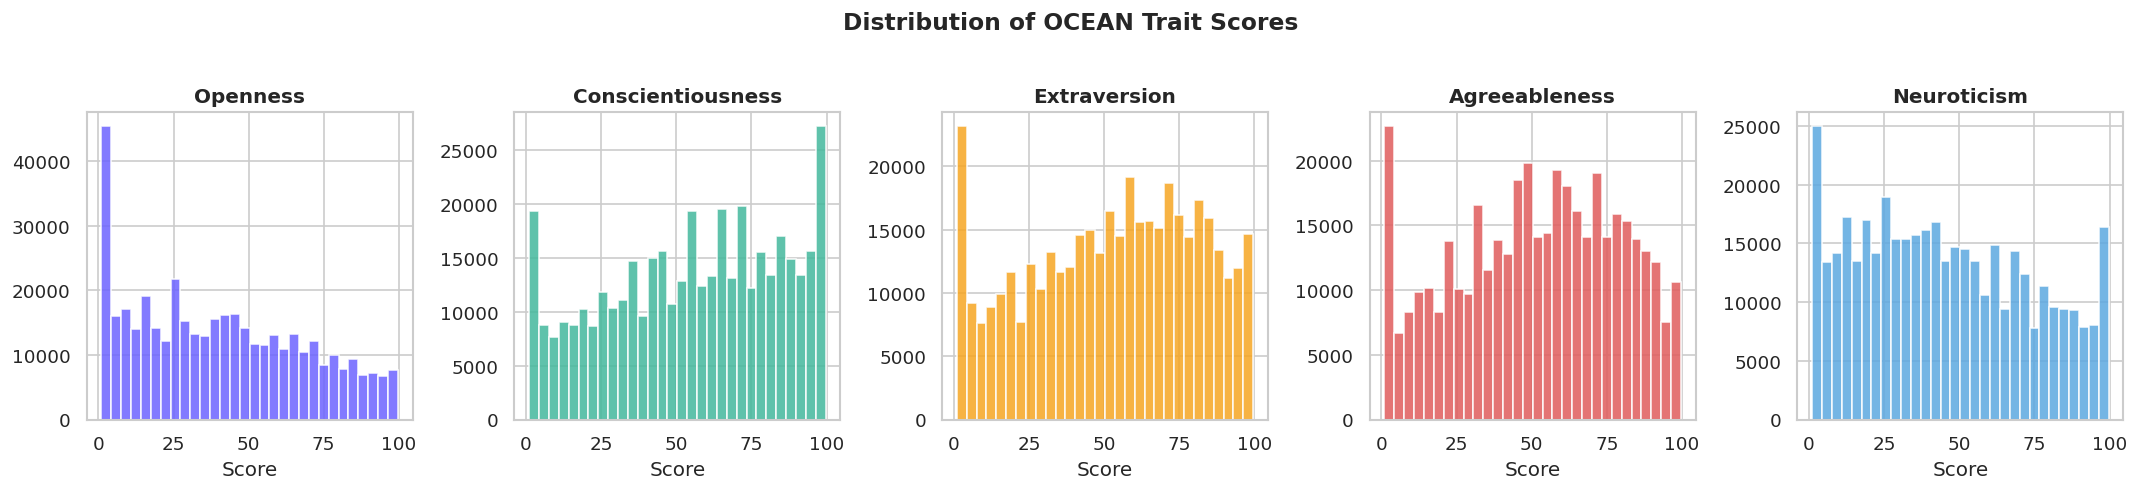

In [ ]:
# Distribution of each trait score
colors = ['#6C63FF', '#43B89C', '#F6A623', '#E05C5C', '#5CA8E0']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, trait, color in zip(axes, trait_cols, colors):
    ax.hist(df[trait].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(TRAIT_MAP[trait], fontweight='bold')
    ax.set_xlabel('Score')

plt.suptitle('Distribution of OCEAN Trait Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

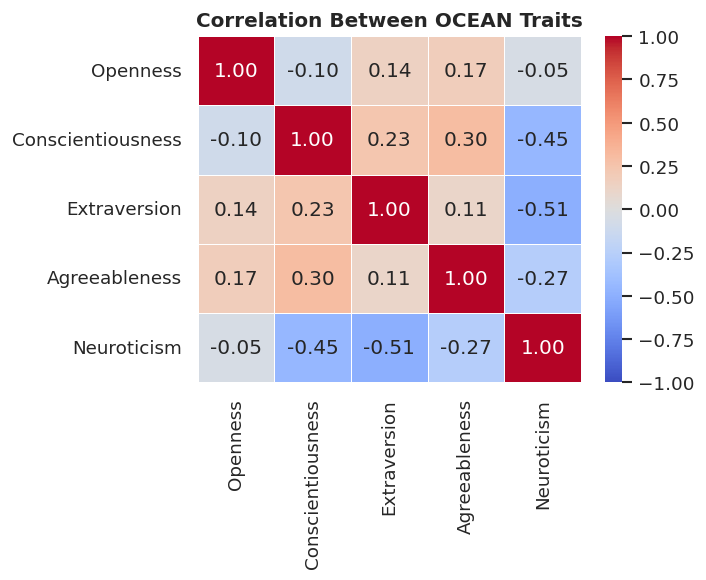

In [ ]:
# Correlation between traits
plt.figure(figsize=(6, 5))
sns.heatmap(df[trait_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=list(TRAIT_MAP.values()),
            yticklabels=list(TRAIT_MAP.values()),
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Between OCEAN Traits', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Create Labels (Low / Medium / High)

In [ ]:
def score_to_class(series):
    """Bin continuous scores into Low / Medium / High using tertiles."""
    low  = series.quantile(0.33)
    high = series.quantile(0.67)
    return pd.cut(series,
                  bins=[-np.inf, low, high, np.inf],
                  labels=['Low', 'Medium', 'High'])

y = pd.DataFrame()
for trait in trait_cols:
    y[trait] = score_to_class(df[trait])

print('Class distribution per trait:')
for trait in trait_cols:
    print(f'\n{TRAIT_MAP[trait]}:')
    print(y[trait].value_counts().to_string())

Class distribution per trait:

Openness:
openness
Medium    138038
Low       136921
High      135417

Conscientiousness:
conscientiousness
Medium    138676
Low       136836
High      134864

Extraversion:
extraversion
Medium    139422
Low       137272
High      133682

Agreeableness:
agreeableness
Low       138425
Medium    136703
High      135248

Neuroticism:
neuroticism
Medium    139013
Low       136800
High      134563


In [ ]:
# Drop rows with NaN
valid_idx = y.dropna().index
X = df.loc[valid_idx, item_cols].fillna(df[item_cols].median())
y_clean = y.loc[valid_idx]

# Drop rows where any facet column has 0 or negative values (invalid responses)
valid_mask = (X > 0).all(axis=1)
X = X[valid_mask]
y_clean = y_clean[valid_mask]

# Reset index
X = X.reset_index(drop=True)
y_clean = y_clean.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean, test_size=0.2, random_state=42,
    stratify=y_clean[trait_cols[0]]
)

print(f'Total samples : {len(X)}')
print(f'Train samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')
print(f'Missing values remaining: {X.isnull().sum().sum()}')

Total samples : 410376
Train samples : 328300
Test samples  : 82076
Missing values remaining: 0


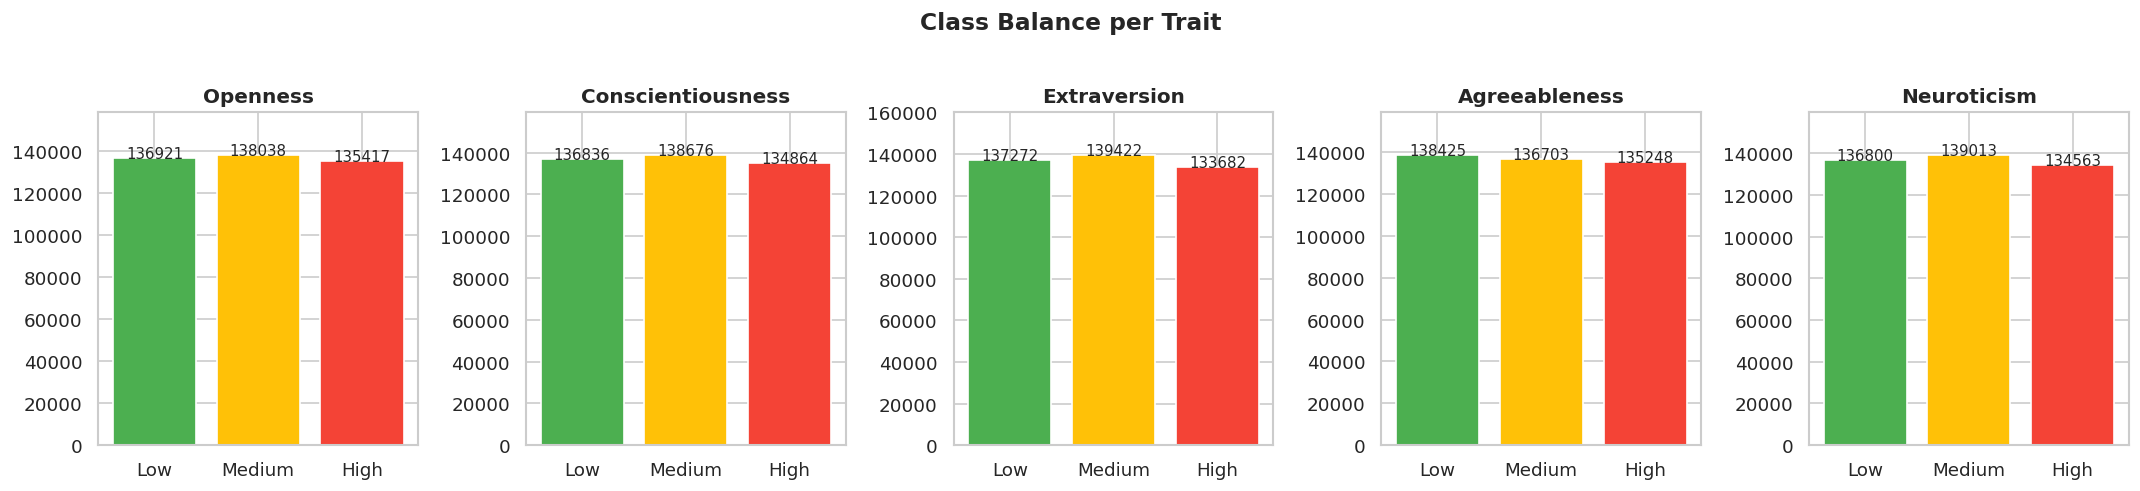

In [ ]:
# Visualize class balance
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors_cls = ['#4CAF50', '#FFC107', '#F44336']

for ax, trait in zip(axes, trait_cols):
    counts = y[trait].value_counts().reindex(['Low', 'Medium', 'High'])
    bars = ax.bar(counts.index, counts.values, color=colors_cls, edgecolor='white')
    ax.set_title(TRAIT_MAP[trait], fontweight='bold')
    ax.set_ylim(0, counts.max() * 1.15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', fontsize=9)

plt.suptitle('Class Balance per Trait', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Train / Test Split

In [ ]:
# Drop rows with NaN
valid_idx = y.dropna().index
X = df.loc[valid_idx, item_cols].fillna(df[item_cols].median())
y_clean = y.loc[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean, test_size=0.2, random_state=42,
    stratify=y_clean[trait_cols[0]]
)

print(f'Total samples : {len(X)}')
print(f'Train samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')

Total samples : 410376
Train samples : 328300
Test samples  : 82076


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features scaled!')
print(f'Mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Std  (should be ~1): {X_train_scaled.std():.4f}')

✅ Features scaled!
Mean (should be ~0): 0.0000
Std  (should be ~1): 1.0000


---
## 7. Train Random Forest

In [ ]:
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
)

rf.fit(X_train, y_train)
print('✅ Model trained!')

✅ Model trained!


---
## 8. Evaluate Model

In [ ]:
y_pred = rf.predict(X_test)

# Accuracy per trait
print(f'{'Trait':<20} {'Accuracy':>10}')
print('-' * 32)
for i, trait in enumerate(trait_cols):
    acc = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
    print(f'{TRAIT_MAP[trait]:<20} {acc:>10.4f}')

Trait                  Accuracy
--------------------------------
Openness                 0.8790
Conscientiousness        0.8362
Extraversion             0.8843
Agreeableness            0.7993
Neuroticism              0.8654


In [ ]:
# Detailed classification report
for i, trait in enumerate(trait_cols):
    print(f'\n── {TRAIT_MAP[trait]} ──')
    print(classification_report(y_test.iloc[:, i], y_pred[:, i],
                                target_names=['Low', 'Medium', 'High']))


── Openness ──
              precision    recall  f1-score   support

         Low       0.92      0.90      0.91     27084
      Medium       0.91      0.90      0.90     27384
        High       0.81      0.84      0.82     27608

    accuracy                           0.88     82076
   macro avg       0.88      0.88      0.88     82076
weighted avg       0.88      0.88      0.88     82076


── Conscientiousness ──
              precision    recall  f1-score   support

         Low       0.89      0.86      0.87     27078
      Medium       0.89      0.86      0.88     27336
        High       0.74      0.78      0.76     27662

    accuracy                           0.84     82076
   macro avg       0.84      0.84      0.84     82076
weighted avg       0.84      0.84      0.84     82076


── Extraversion ──
              precision    recall  f1-score   support

         Low       0.92      0.89      0.91     26796
      Medium       0.93      0.90      0.91     27426
        High  

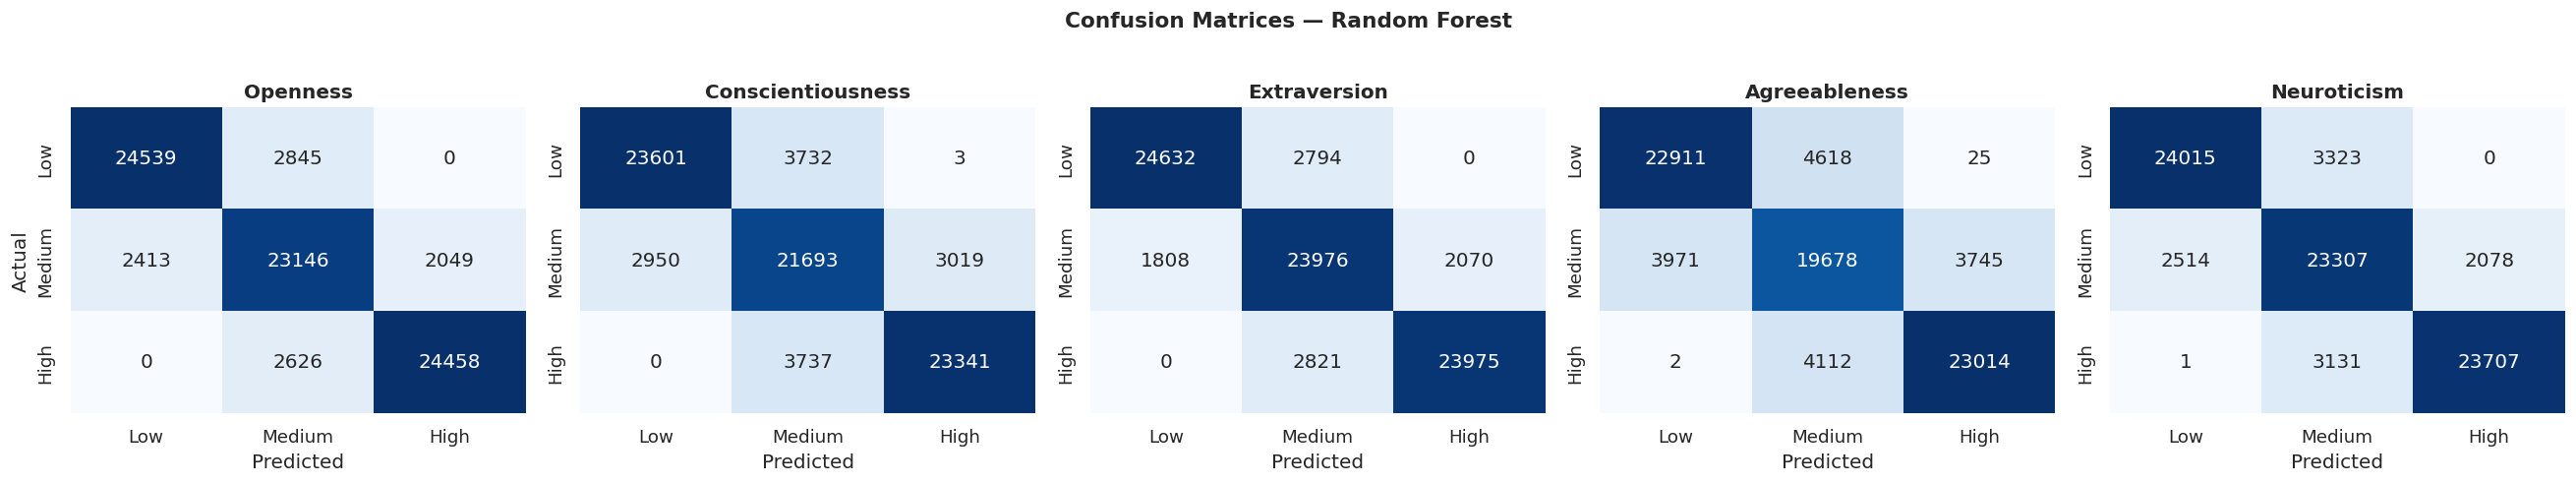

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
classes = ['Low', 'Medium', 'High']

for i, (ax, trait) in enumerate(zip(axes, trait_cols)):
    cm = confusion_matrix(y_test.iloc[:, i], y_pred[:, i], labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes, cbar=False)
    ax.set_title(TRAIT_MAP[trait], fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual' if i == 0 else '')

plt.suptitle('Confusion Matrices — Random Forest', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance

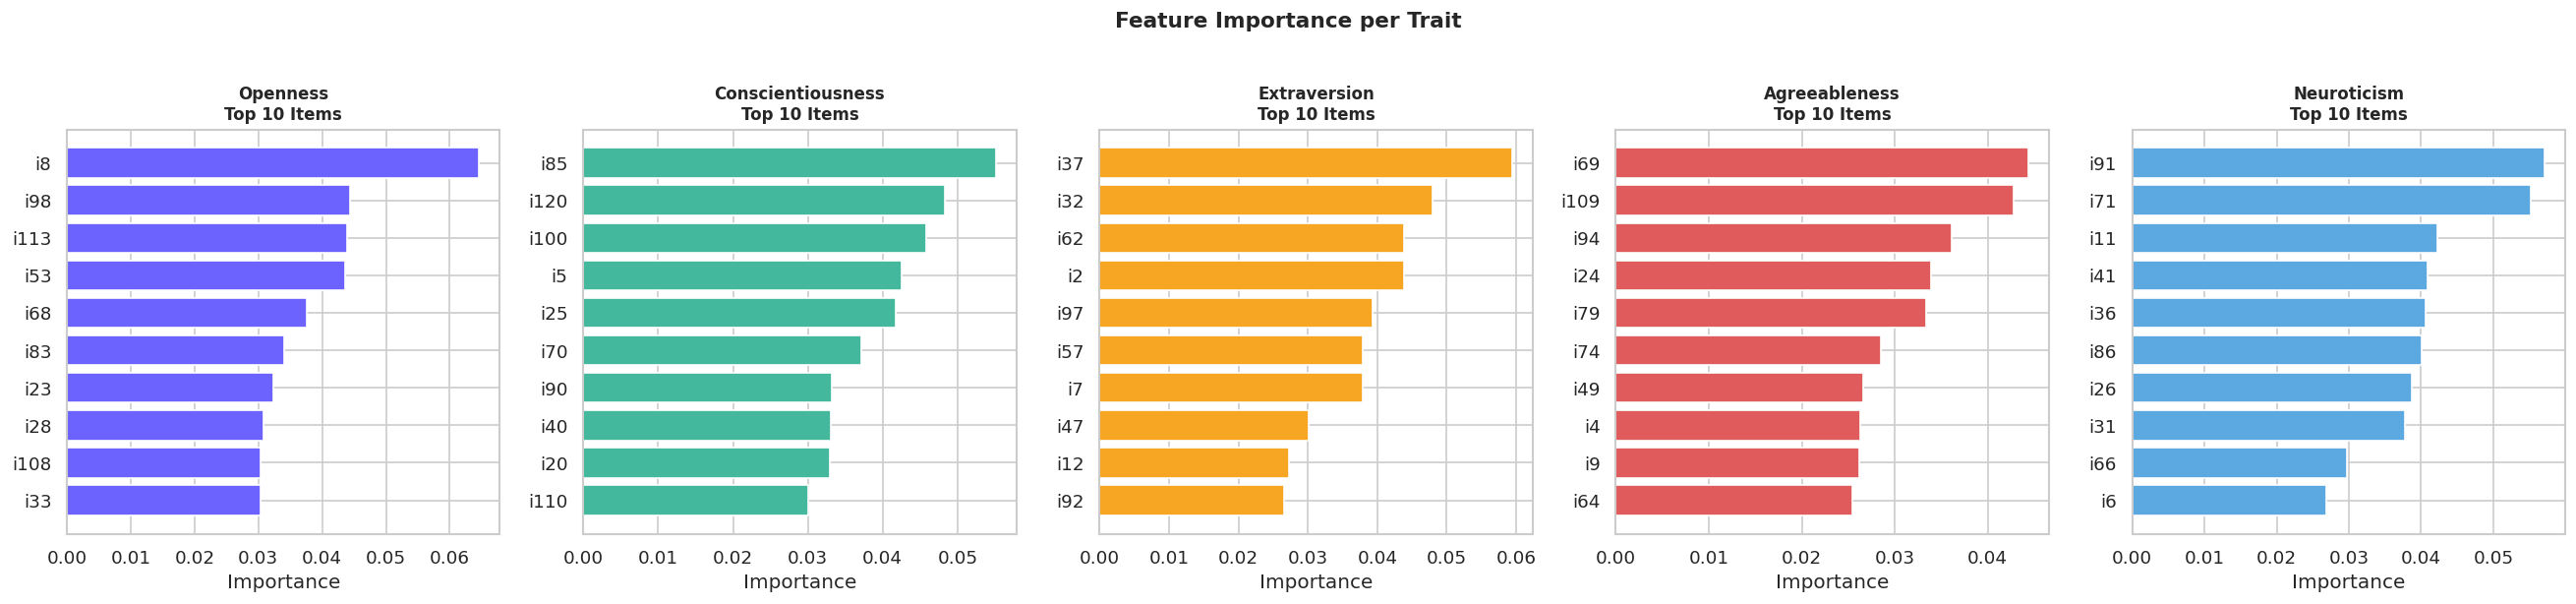

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
colors = ['#6C63FF', '#43B89C', '#F6A623', '#E05C5C', '#5CA8E0']

for ax, estimator, trait, color in zip(axes, rf.estimators_, trait_cols, colors):
    importances = estimator.feature_importances_
    top_idx  = np.argsort(importances)[-10:]
    top_feats = [item_cols[i] for i in top_idx]
    top_vals  = importances[top_idx]

    ax.barh(top_feats, top_vals, color=color, edgecolor='white')
    ax.set_title(f'{TRAIT_MAP[trait]}\nTop 10 Items', fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance per Trait', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning

In [ ]:
TARGET_TRAIT = 'extraversion'
target_idx   = trait_cols.index(TARGET_TRAIT)

param_dist = {
    'n_estimators'     : randint(50, 200),
    'max_depth'        : [5, 10, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=1
)

search.fit(X_train, y_train.iloc[:, target_idx])

print(f'\nBest params: {search.best_params_}')
print(f'Best CV accuracy : {search.best_score_:.4f}')

y_pred_tuned = search.best_estimator_.predict(X_test)
print(f'Test accuracy (tuned)  : {accuracy_score(y_test.iloc[:, target_idx], y_pred_tuned):.4f}')
print(f'Test accuracy (default): {accuracy_score(y_test.iloc[:, target_idx], y_pred[:, target_idx]):.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 139}
Best CV accuracy : 0.8807
Test accuracy (tuned)  : 0.8822
Test accuracy (default): 0.8843


---
## 11. Test on Dataset Row

In [ ]:
row_index = 0  # change to any row number

sample = X_test.iloc[[row_index]]
actual = y_test.iloc[row_index]
pred   = rf.predict(sample)

print('=== Prediction vs Actual ===')
print(f'{"Trait":<20} {"Predicted":<12} {"Actual":<12} {"Match"}')
print('-' * 55)
for i, trait in enumerate(trait_cols):
    match = '✅' if pred[0][i] == actual[trait] else '❌'
    print(f'{TRAIT_MAP[trait]:<20} {pred[0][i]:<12} {str(actual[trait]):<12} {match}')

=== Prediction vs Actual ===
Trait                Predicted    Actual       Match
-------------------------------------------------------
Openness             Low          Low          ✅
Conscientiousness    High         High         ✅
Extraversion         Low          Low          ✅
Agreeableness        Medium       Medium       ✅
Neuroticism          High         High         ✅


---
## 12. Predict from User Input (All 120 Questions)

In [ ]:
import joblib
import numpy as np

# ── 1. Load model and scaler ──────────────────────────────────
rf     = joblib.load('personality_model.pkl')
scaler = joblib.load('personality_scaler.pkl')
print('✅ Model loaded!')
# Run this in your notebook
print("Correct column order for predict.py:")
for col in item_cols:
    print(col)
# ── 2. Define trait info ──────────────────────────────────────
trait_cols = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']

TRAIT_MAP = {
    'openness'          : 'Openness',
    'conscientiousness' : 'Conscientiousness',
    'extraversion'      : 'Extraversion',
    'agreeableness'     : 'Agreeableness',
    'neuroticism'       : 'Neuroticism'
}

# ── 3. Personality type function ──────────────────────────────
def get_personality_type(pred, trait_cols):
    profile = {trait: pred[0][i] for i, trait in enumerate(trait_cols)}

    o = profile['openness']
    c = profile['conscientiousness']
    e = profile['extraversion']
    a = profile['agreeableness']
    n = profile['neuroticism']

    if e == 'High' and a == 'High' and n == 'Low':
        ptype = 'The Leader'
        desc  = 'Charismatic, warm, and emotionally stable. Natural at bringing people together.'

    elif o == 'High' and e == 'High' and a == 'High':
        ptype = 'The Entertainer'
        desc  = 'Creative, sociable, and fun-loving. Loves being around people and new experiences.'

    elif c == 'High' and o == 'High' and n == 'Low':
        ptype = 'The Achiever'
        desc  = 'Disciplined, curious, and focused. Highly goal-oriented and reliable.'

    elif a == 'High' and n == 'Low' and e == 'Low':
        ptype = 'The Caregiver'
        desc  = 'Empathetic, calm, and supportive. Puts others first and avoids conflict.'

    elif o == 'High' and e == 'Low' and c == 'High':
        ptype = 'The Thinker'
        desc  = 'Intellectual, introspective, and methodical. Prefers ideas over socializing.'

    elif n == 'High' and e == 'Low' and a == 'Low':
        ptype = 'The Lone Wolf'
        desc  = 'Independent, intense, and private. Prefers solitude and deep thought.'

    elif c == 'High' and a == 'High' and e == 'Low':
        ptype = 'The Defender'
        desc  = 'Reliable, kind, and hardworking. Quietly dedicated to helping others.'

    elif o == 'Low' and c == 'Low' and n == 'High':
        ptype = 'The Struggler'
        desc  = 'Sensitive and easily stressed. May need more support and structure.'

    elif o == 'High' and a == 'Low' and e == 'High':
        ptype = 'The Debater'
        desc  = 'Bold, curious, and argumentative. Loves challenging ideas and people.'

    elif c == 'Low' and o == 'Low' and e == 'High':
        ptype = 'The Adventurer'
        desc  = 'Spontaneous, energetic, and thrill-seeking. Lives in the moment.'

    else:
        ptype = 'The Balanced'
        desc  = 'A well-rounded mix of traits. Adaptable across different situations.'

    return ptype, desc

# ── 4. All 120 questions ──────────────────────────────────────
questions = [
    "Worry about things.",
    "Make friends easily.",
    "Have a vivid imagination.",
    "Trust others.",
    "Complete tasks successfully.",
    "Get angry easily.",
    "Love large parties.",
    "Believe in the importance of art.",
    "Use others for my own ends.",
    "Like to tidy up.",
    "Often feel blue.",
    "Take charge.",
    "Experience my emotions intensely.",
    "Love to help others.",
    "Keep my promises.",
    "Find it difficult to approach others.",
    "Am always busy.",
    "Prefer variety to routine.",
    "Love a good fight.",
    "Work hard.",
    "Go on binges.",
    "Love excitement.",
    "Love to read challenging material.",
    "Believe that I am better than others.",
    "Am always prepared.",
    "Panic easily.",
    "Radiate joy.",
    "Tend to vote for liberal political candidates.",
    "Sympathize with the homeless.",
    "Jump into things without thinking.",
    "Fear for the worst.",
    "Feel comfortable around other people.",
    "Enjoy wild flights of fantasy.",
    "Believe that others have good intentions.",
    "Excel in what I do.",
    "Get irritated easily.",
    "Talk to a lot of different people at parties.",
    "See beauty in things that others might not notice.",
    "Cheat to get ahead.",
    "Often forget to put things back in their proper place.",
    "Dislike myself.",
    "Try to lead others.",
    "Feel others' emotions.",
    "Am concerned about others.",
    "Tell the truth.",
    "Am afraid to draw attention to myself.",
    "Am always on the go.",
    "Prefer to stick with things that I know.",
    "Yell at people.",
    "Do more than what's expected of me.",
    "Rarely overindulge.",
    "Seek adventure.",
    "Avoid philosophical discussions.",
    "Think highly of myself.",
    "Carry out my plans.",
    "Become overwhelmed by events.",
    "Have a lot of fun.",
    "Believe that there is no absolute right or wrong.",
    "Feel sympathy for those who are worse off than myself.",
    "Make rash decisions.",
    "Am afraid of many things.",
    "Avoid contacts with others.",
    "Love to daydream.",
    "Trust what people say.",
    "Handle tasks smoothly.",
    "Lose my temper.",
    "Prefer to be alone.",
    "Do not like poetry.",
    "Take advantage of others.",
    "Leave a mess in my room.",
    "Am often down in the dumps.",
    "Take control of things.",
    "Rarely notice my emotional reactions.",
    "Am indifferent to the feelings of others.",
    "Break rules.",
    "Only feel comfortable with friends.",
    "Do a lot in my spare time.",
    "Dislike changes.",
    "Insult people.",
    "Do just enough work to get by.",
    "Easily resist temptations.",
    "Enjoy being reckless.",
    "Have difficulty understanding abstract ideas.",
    "Have a high opinion of myself.",
    "Waste my time.",
    "Feel that I'm unable to deal with things.",
    "Love life.",
    "Tend to vote for conservative political candidates.",
    "Am not interested in other people's problems.",
    "Rush into things.",
    "Get stressed out easily.",
    "Keep others at a distance.",
    "Like to get lost in thought.",
    "Distrust people.",
    "Know how to get things done.",
    "Am not easily annoyed.",
    "Avoid crowds.",
    "Do not enjoy going to art museums.",
    "Obstruct others' plans.",
    "Leave my belongings around.",
    "Feel comfortable with myself.",
    "Wait for others to lead the way.",
    "Don't understand people who get emotional.",
    "Take no time for others.",
    "Break my promises.",
    "Am not bothered by difficult social situations.",
    "Like to take it easy.",
    "Am attached to conventional ways.",
    "Get back at others.",
    "Put little time and effort into my work.",
    "Am able to control my cravings.",
    "Act wild and crazy.",
    "Am not interested in theoretical discussions.",
    "Boast about my virtues.",
    "Have difficulty starting tasks.",
    "Remain calm under pressure.",
    "Look at the bright side of life.",
    "Believe that we should be tough on crime.",
    "Try not to think about the needy.",
    "Act without thinking.",
]

# ── 5. Collect responses ──────────────────────────────────────
print('\nRate each statement: 1=Inaccurate → 5=Accurate\n')

responses = []
for i, q in enumerate(questions):
    while True:
        try:
            val = int(input(f'Q{i+1}/120 — {q} '))
            if 1 <= val <= 5:
                responses.append(val)
                break
            else:
                print('  ⚠️ Enter 1–5')
        except ValueError:
            print('  ⚠️ Numbers only')

# ── 6. Scale and predict ──────────────────────────────────────
user_input = scaler.transform(np.array([responses]))
pred       = rf.predict(user_input)

# ── 7. Show trait results ─────────────────────────────────────
print('\n=== Your Personality Profile ===')
print(f'{"Trait":<20} {"Level"}')
print('-' * 32)
for i, trait in enumerate(trait_cols):
    print(f'{TRAIT_MAP[trait]:<20} → {pred[0][i]}')

# ── 8. Show personality type ──────────────────────────────────
ptype, desc = get_personality_type(pred, trait_cols)
print(f'\n🧠 Personality Type : {ptype}')
print(f'📝 Description      : {desc}')

✅ Model loaded!
Correct column order for predict.py:
i1
i2
i3
i4
i5
i6
i7
i8
i9
i10
i11
i12
i13
i14
i15
i16
i17
i18
i19
i20
i21
i22
i23
i24
i25
i26
i27
i28
i29
i30
i31
i32
i33
i34
i35
i36
i37
i38
i39
i40
i41
i42
i43
i44
i45
i46
i47
i48
i49
i50
i51
i52
i53
i54
i55
i56
i57
i58
i59
i60
i61
i62
i63
i64
i65
i66
i67
i68
i69
i70
i71
i72
i73
i74
i75
i76
i77
i78
i79
i80
i81
i82
i83
i84
i85
i86
i87
i88
i89
i90
i91
i92
i93
i94
i95
i96
i97
i98
i99
i100
i101
i102
i103
i104
i105
i106
i107
i108
i109
i110
i111
i112
i113
i114
i115
i116
i117
i118
i119
i120

Rate each statement: 1=Inaccurate → 5=Accurate



KeyboardInterrupt: Interrupted by user

---
## 13. Save Model

In [ ]:
import joblib


joblib.dump(rf, 'personality_model.pkl')
print(f'✅ Model saved → personality_model.pkl')
joblib.dump(scaler, 'personality_scaler.pkl')
joblib.dump(item_cols, 'feature_columns.pkl')

✅ Model saved → personality_model.pkl


['feature_columns.pkl']

In [ ]:
import joblib
import os

# Change this to your Google Drive path
drive_path = '/content/drive/MyDrive/Colab Notebooks/'

# Create folder if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# Save model
joblib.dump(rf, drive_path + 'personality_model.pkl')
print(f'✅ Model saved → {drive_path}personality_model.pkl')

✅ Model saved → /content/drive/MyDrive/Colab Notebooks/personality_model.pkl


In [ ]:
joblib.dump(scaler, drive_path + 'personality_scaler.pkl')

['/content/drive/MyDrive/Colab Notebooks/personality_scaler.pkl']

In [ ]:
print("Correct column order for predict.py:")
for col in item_cols:
    print(col)

Correct column order for predict.py:
i1
i2
i3
i4
i5
i6
i7
i8
i9
i10
i11
i12
i13
i14
i15
i16
i17
i18
i19
i20
i21
i22
i23
i24
i25
i26
i27
i28
i29
i30
i31
i32
i33
i34
i35
i36
i37
i38
i39
i40
i41
i42
i43
i44
i45
i46
i47
i48
i49
i50
i51
i52
i53
i54
i55
i56
i57
i58
i59
i60
i61
i62
i63
i64
i65
i66
i67
i68
i69
i70
i71
i72
i73
i74
i75
i76
i77
i78
i79
i80
i81
i82
i83
i84
i85
i86
i87
i88
i89
i90
i91
i92
i93
i94
i95
i96
i97
i98
i99
i100
i101
i102
i103
i104
i105
i106
i107
i108
i109
i110
i111
i112
i113
i114
i115
i116
i117
i118
i119
i120


In [ ]:
# Add this temporarily to predict.py to test
import pandas as pd

df     = pd.read_csv('/content/drive/MyDrive/IPIP120-SCORES.csv')
sample = df[item_cols].iloc[[0]]  # use item_cols from notebook
sample_scaled = scaler.transform(sample)
pred   = rf.predict(sample_scaled)

print('Test prediction:')
for i, trait in enumerate(trait_cols):
    print(f'{TRAIT_MAP[trait]:<20} → {pred[0][i]}')

Test prediction:
Openness             → Low
Conscientiousness    → Low
Extraversion         → Low
Agreeableness        → Low
Neuroticism          → Low


In [ ]:
# Check 1 — does the model predict anything other than Low on dataset rows?
sample = X_test.iloc[[0]]
pred_test = rf.predict(sample)
print('Test row prediction:')
for i, trait in enumerate(trait_cols):
    print(f'{TRAIT_MAP[trait]:<20} → {pred_test[0][i]}')

Test row prediction:
Openness             → Low
Conscientiousness    → High
Extraversion         → Low
Agreeableness        → Medium
Neuroticism          → High


In [ ]:
# Check 2 — what are the unique classes the model knows?
for i, estimator in enumerate(rf.estimators_):
    print(f'{trait_cols[i]}: {estimator.classes_}')

openness: ['High' 'Low' 'Medium']
conscientiousness: ['High' 'Low' 'Medium']
extraversion: ['High' 'Low' 'Medium']
agreeableness: ['High' 'Low' 'Medium']
neuroticism: ['High' 'Low' 'Medium']


In [ ]:
# Fix in notebook before training
for trait in trait_cols:
    y[trait] = y[trait].astype(str)  # convert from category to string